In [3]:
import pandas as pd
import numpy as np
#%pip install xgboost
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import pickle, json, os

os.makedirs('../app', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

# Load data 
df = pd.read_csv('../data/raw/Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv')
print("Shape:", df.shape)
print()
print(df.dtypes)
print()
print("=== Segment distribution ===")
print(df['segment'].value_counts())
print()
print("=== Visit rate per segment ===")
print(df.groupby('segment')[['visit','conversion','spend']].mean().round(4))
print()
print("=== Missing values ===")
print(df.isnull().sum())

Shape: (64000, 12)

recency              int64
history_segment     object
history            float64
mens                 int64
womens               int64
zip_code            object
newbie               int64
channel             object
segment             object
visit                int64
conversion           int64
spend              float64
dtype: object

=== Segment distribution ===
segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64

=== Visit rate per segment ===
                visit  conversion   spend
segment                                  
Mens E-Mail    0.1828      0.0125  1.4226
No E-Mail      0.1062      0.0057  0.6528
Womens E-Mail  0.1514      0.0088  1.0772

=== Missing values ===
recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
segment            0
visit              0
conversion         0
spend       

Treatment=1 (Womens): 21,387
Treatment=0 (Control): 21,306
Visit rate — treatment: 0.1514
Visit rate — control:   0.1062
Naive ATE (visit):      0.0452

Feature cols: ['recency', 'history', 'mens', 'womens', 'newbie', 'zip_encoded', 'channel_encoded']
X_t shape: (21387, 7), positive rate: 0.1514
X_c shape: (21306, 7), positive rate: 0.1062
Model T — train AUC: 0.6768
Model C — train AUC: 0.6999

Uplift score stats:
count    42693.0000
mean         0.0453
std          0.0525
min         -0.2480
25%          0.0108
50%          0.0413
75%          0.0793
max          0.3343
Name: uplift_score, dtype: float64

Positive uplift: 82.9%
Negative uplift: 17.1%
=== Uplift segment distribution ===
uplift_segment
Needs Attention    14051
Sure Things        10674
Persuadables       10674
Lost Causes         7294
Name: count, dtype: int64

=== Visit rate: treatment vs control per uplift segment ===
  Persuadables       T=0.237  C=0.084  lift=+0.153
  Sure Things        T=0.157  C=0.090  lift=+0.067

C:\Users\HP\AppData\Local\Temp\ipykernel_16432\3267696446.py:138: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auuc = np.trapz(qini_y, qini_x) - np.trapz(rand_y, qini_x)


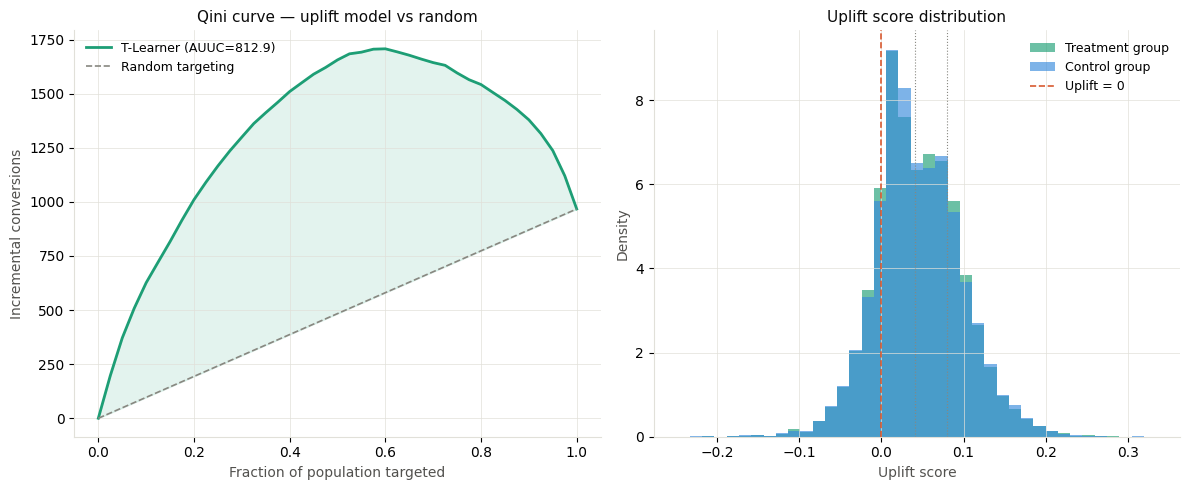

Saved: qini_curve.png — AUUC = 812.87


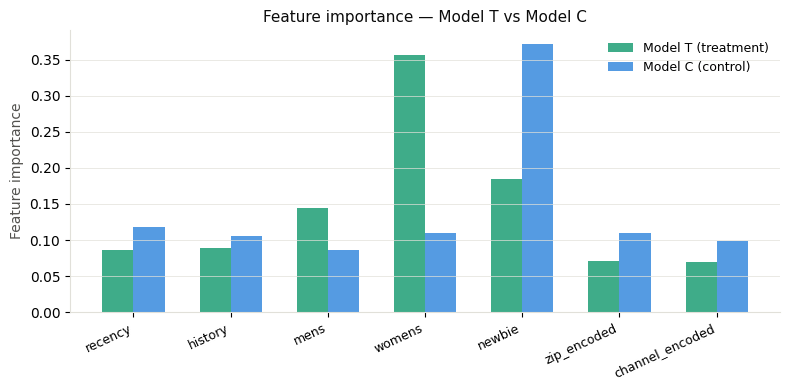

Saved: feature_importance.png
Exported: xgb_treatment_model.pkl
Exported: xgb_control_model.pkl
Exported: feature_cols.json — ['recency', 'history', 'mens', 'womens', 'newbie', 'zip_encoded', 'channel_encoded']
Exported: uplift_scores.csv — 42,693 rows

=== Final uplift segment breakdown ===
                 customers  avg_uplift  visit_rate
uplift_segment                                    
Lost Causes           7294     -0.0275      0.1422
Needs Attention      14051      0.0202      0.1015
Persuadables         10674      0.1130      0.1610
Sure Things          10674      0.0603      0.1235

AUUC: 812.8725
p50 cut: 0.0413
p75 cut: 0.0793


In [4]:
#  Preprocessing + Treatment/Control split
# Filter: Womens E-Mail vs No E-Mail only
df_model = df[df['segment'].isin(['Womens E-Mail', 'No E-Mail'])].copy()
df_model['treatment'] = (df_model['segment'] == 'Womens E-Mail').astype(int)

print(f"Treatment=1 (Womens): {df_model['treatment'].sum():,}")
print(f"Treatment=0 (Control): {(df_model['treatment']==0).sum():,}")
print(f"Visit rate — treatment: {df_model[df_model['treatment']==1]['visit'].mean():.4f}")
print(f"Visit rate — control:   {df_model[df_model['treatment']==0]['visit'].mean():.4f}")
print(f"Naive ATE (visit):      {df_model[df_model['treatment']==1]['visit'].mean() - df_model[df_model['treatment']==0]['visit'].mean():.4f}")

# Encode categoricals
le_zip     = LabelEncoder()
le_channel = LabelEncoder()
df_model['zip_encoded']     = le_zip.fit_transform(df_model['zip_code'])
df_model['channel_encoded'] = le_channel.fit_transform(df_model['channel'])

FEATURE_COLS = [
    'recency', 'history', 'mens', 'womens',
    'newbie', 'zip_encoded', 'channel_encoded'
]
json.dump(FEATURE_COLS, open('../app/feature_cols.json','w'))

X = df_model[FEATURE_COLS].values
y = df_model['visit'].values
t = df_model['treatment'].values

# Split treatment / control
X_t, y_t = X[t == 1], y[t == 1]
X_c, y_c = X[t == 0], y[t == 0]

print(f"\nFeature cols: {FEATURE_COLS}")
print(f"X_t shape: {X_t.shape}, positive rate: {y_t.mean():.4f}")
print(f"X_c shape: {X_c.shape}, positive rate: {y_c.mean():.4f}")

# Train T-Learner (2 independent XGBoost models)

XGB_PARAMS = dict(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=20,  
    eval_metric='auc',
    random_state=42,
    verbosity=0
)

# Model T — train trên treatment group
model_t = XGBClassifier(**XGB_PARAMS)
model_t.fit(X_t, y_t)
auc_t = roc_auc_score(y_t, model_t.predict_proba(X_t)[:,1])

# Model C — train trên control group
model_c = XGBClassifier(**XGB_PARAMS)
model_c.fit(X_c, y_c)
auc_c = roc_auc_score(y_c, model_c.predict_proba(X_c)[:,1])

print(f"Model T — train AUC: {auc_t:.4f}")
print(f"Model C — train AUC: {auc_c:.4f}")

# Uplift score = apply BOTH models to ALL customers in df_model
uplift = (model_t.predict_proba(X)[:,1]
        - model_c.predict_proba(X)[:,1])

df_model = df_model.copy()
df_model['uplift_score'] = uplift
df_model['p_t'] = model_t.predict_proba(X)[:,1]
df_model['p_c'] = model_c.predict_proba(X)[:,1]

print(f"\nUplift score stats:")
print(df_model['uplift_score'].describe().round(4))
print(f"\nPositive uplift: {(uplift > 0).mean()*100:.1f}%")
print(f"Negative uplift: {(uplift < 0).mean()*100:.1f}%")

# Uplift segments + Qini curve

# Classify into 4 uplift segments
p50 = np.percentile(uplift, 50)
p75 = np.percentile(uplift, 75)

def classify_uplift(row):
    u = row['uplift_score']
    if u >= p75:
        return 'Persuadables'
    elif u >= p50:
        return 'Sure Things'
    elif u >= 0:
        return 'Needs Attention'
    else:
        return 'Lost Causes'

df_model['uplift_segment'] = df_model.apply(classify_uplift, axis=1)

print("=== Uplift segment distribution ===")
print(df_model['uplift_segment'].value_counts())
print()

# Visit rate per uplift segment (trong treatment group)
treat_only = df_model[df_model['treatment'] == 1]
ctrl_only  = df_model[df_model['treatment'] == 0]

print("=== Visit rate: treatment vs control per uplift segment ===")
for seg in ['Persuadables','Sure Things','Needs Attention','Lost Causes']:
    vt = treat_only[treat_only['uplift_segment'] == seg]['visit'].mean()
    vc = ctrl_only [ctrl_only ['uplift_segment'] == seg]['visit'].mean()
    print(f"  {seg:<18} T={vt:.3f}  C={vc:.3f}  lift={vt-vc:+.3f}")
print()
print(f"Percentile cuts — p50: {p50:.4f}, p75: {p75:.4f}")

#  Qini curve + all visualizations

def compute_qini(df, uplift_col, treatment_col, outcome_col, n_bins=40):
    df_s = df.sort_values(uplift_col, ascending=False).reset_index(drop=True)
    n = len(df_s)
    n_t = df_s[treatment_col].sum()
    n_c = n - n_t
    qini_x, qini_y, random_y = [0.0], [0.0], [0.0]
    for i in range(1, n_bins + 1):
        idx = int(i / n_bins * n)
        sub = df_s.iloc[:idx]
        nt_sub = sub[treatment_col].sum()
        nc_sub = len(sub) - nt_sub
        yt_sub = sub[sub[treatment_col]==1][outcome_col].sum()
        yc_sub = sub[sub[treatment_col]==0][outcome_col].sum() if nc_sub>0 else 0
        qini_val = yt_sub - yc_sub * (nt_sub / n_c) if n_c > 0 else 0
        qini_x.append(i / n_bins)
        qini_y.append(qini_val)
        random_y.append(i / n_bins * (
            df_s[df_s[treatment_col]==1][outcome_col].sum()
            - df_s[df_s[treatment_col]==0][outcome_col].sum() * n_t/n_c
        ))
    return np.array(qini_x), np.array(qini_y), np.array(random_y)

qini_x, qini_y, rand_y = compute_qini(
    df_model, 'uplift_score', 'treatment', 'visit')
auuc = np.trapz(qini_y, qini_x) - np.trapz(rand_y, qini_x)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('white')

# — Left: Qini curve —
ax = axes[0]
ax.set_facecolor('white')
ax.plot(qini_x, qini_y,  color='#1D9E75', lw=2,   label=f'T-Learner (AUUC={auuc:.1f})')
ax.plot(qini_x, rand_y,  color='#888780', lw=1.2,
        linestyle='--', label='Random targeting')
ax.fill_between(qini_x, qini_y, rand_y,
                alpha=0.12, color='#1D9E75')
ax.set_xlabel('Fraction of population targeted', fontsize=10, color='#52514e')
ax.set_ylabel('Incremental conversions', fontsize=10, color='#52514e')
ax.set_title('Qini curve — uplift model vs random', fontsize=11,
             fontweight='normal', color='#0b0b0b')
ax.legend(fontsize=9, frameon=False)
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#e1e0d9')
ax.grid(True, color='#e1e0d9', linewidth=0.5)

# — Right: Uplift score distribution by treatment —
ax2 = axes[1]
ax2.set_facecolor('white')
bins = np.linspace(uplift.min(), uplift.max(), 40)
ax2.hist(df_model[df_model['treatment']==1]['uplift_score'],
         bins=bins, alpha=0.65, color='#1D9E75',
         label='Treatment group', density=True)
ax2.hist(df_model[df_model['treatment']==0]['uplift_score'],
         bins=bins, alpha=0.65, color='#378ADD',
         label='Control group',   density=True)
ax2.axvline(0, color='#D85A30', lw=1.2, linestyle='--', label='Uplift = 0')
ax2.axvline(p50, color='#888780', lw=0.8, linestyle=':')
ax2.axvline(p75, color='#888780', lw=0.8, linestyle=':')
ax2.set_xlabel('Uplift score', fontsize=10, color='#52514e')
ax2.set_ylabel('Density', fontsize=10, color='#52514e')
ax2.set_title('Uplift score distribution', fontsize=11,
              fontweight='normal', color='#0b0b0b')
ax2.legend(fontsize=9, frameon=False)
ax2.spines[['top','right']].set_visible(False)
ax2.spines[['left','bottom']].set_color('#e1e0d9')
ax2.grid(True, color='#e1e0d9', linewidth=0.5)

plt.tight_layout()
plt.savefig('../reports/qini_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: qini_curve.png — AUUC = {auuc:.2f}")

# — Fig 2: Feature importance —
fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

imp_t = model_t.feature_importances_
imp_c = model_c.feature_importances_
imp_diff = imp_t - imp_c   # features more important in T vs C model
x = np.arange(len(FEATURE_COLS))
w = 0.32
ax.bar(x - w/2, imp_t, width=w, color='#1D9E75', alpha=0.85, label='Model T (treatment)')
ax.bar(x + w/2, imp_c, width=w, color='#378ADD', alpha=0.85, label='Model C (control)')
ax.set_xticks(x)
ax.set_xticklabels(FEATURE_COLS, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Feature importance', fontsize=10, color='#52514e')
ax.set_title('Feature importance — Model T vs Model C', fontsize=11,
             fontweight='normal', color='#0b0b0b')
ax.legend(fontsize=9, frameon=False)
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#e1e0d9')
ax.grid(True, axis='y', color='#e1e0d9', linewidth=0.5)
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")

#  Export artifacts

# Save models
pickle.dump(model_t, open('../app/xgb_treatment_model.pkl','wb'))
pickle.dump(model_c, open('../app/xgb_control_model.pkl','wb'))

# Save uplift scores
uplift_export = df_model[[
    'recency','history','mens','womens','newbie',
    'zip_code','channel','segment','treatment',
    'visit','conversion','spend',
    'uplift_score','p_t','p_c','uplift_segment'
]].copy()
uplift_export.to_csv('../app/uplift_scores.csv', index=False)

print(f"Exported: xgb_treatment_model.pkl")
print(f"Exported: xgb_control_model.pkl")
print(f"Exported: feature_cols.json — {FEATURE_COLS}")
print(f"Exported: uplift_scores.csv — {uplift_export.shape[0]:,} rows")
print()
print("=== Final uplift segment breakdown ===")
summary = (df_model.groupby('uplift_segment').agg(
    customers=('uplift_score','count'),
    avg_uplift=('uplift_score','mean'),
    visit_rate=('visit','mean')
).round(4))
print(summary)
print()
print(f"AUUC: {auuc:.4f}")
print(f"p50 cut: {p50:.4f}")
print(f"p75 cut: {p75:.4f}")